# 04 · Reading results — everything an `SMatrix` tells you

Every engine returns the same object: a canonical `SMatrix` (complex,
multi-port, multi-mode). This notebook is a tour of what you can *read* from
it — magnitudes, loss, phase, the physical sanity checks, and file I/O — all
**offline and free** (we load a recorded y-branch result, no engine needed).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from gds_fdtd.plotting import plot_smatrix, smatrix_summary
from gds_fdtd.smatrix import SMatrix


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)


sm = SMatrix.from_npz(str(_find("examples/07_choosing_an_engine/recorded/ybranch_tidy3d.npz")))
print(f"{sm.name}: {sm.n_ports} ports {sm.port_names}, {sm.n_modes} mode(s), "
      f"{sm.wavelength_um.size} wavelengths {sm.wavelength_um.min():.3f}–{sm.wavelength_um.max():.3f} µm")

ebeam_y_1550: 3 ports ['opt1', 'opt2', 'opt3'], 1 mode(s), 5 wavelengths 1.500–1.600 µm


## 1 · The raw array

Under the hood `sm.s` is a complex array indexed `[wavelength, out, in, mode_out,
mode_in]`. You rarely touch it directly — `sm.sel(out, in_, ...)` pulls one path
by port **name or number** and is the friendly way in.

In [2]:
s21 = sm.sel(out=2, in_=1)  # complex transmission opt1 -> opt2 vs wavelength
print("S(opt2<-opt1) complex, first 3 wavelengths:", np.round(s21[:3], 4))

S(opt2<-opt1) complex, first 3 wavelengths: [ 0.3593+0.5909j  0.2685-0.6395j -0.6889+0.0593j]


## 2 · Magnitudes and the split

`plot_smatrix` overlays every measured path in dB (`|S|²`). A y-branch splits
its input evenly, so the two transmission paths sit near −3 dB and the
reflection sits far below.

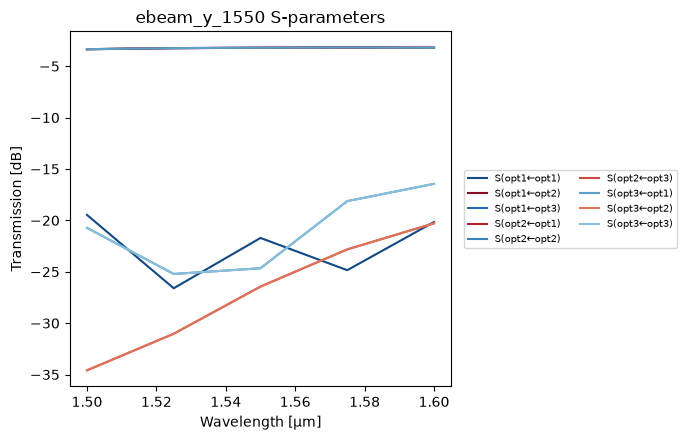

In [3]:
plot_smatrix(sm, kind="db")
plt.show()

## 3 · Figures of merit

`smatrix_summary` reduces the matrix to the numbers you quote in a report —
insertion/return loss per path at band center, plus the physical checks.

In [4]:
summary = smatrix_summary(sm)
print(f"at {summary['wavelength_um']} µm:  reciprocal={summary['reciprocal']}  "
      f"passive={summary['passive']}  max power imbalance={summary['max_power_imbalance']}")
for p in summary["paths"]:
    kind = "insertion loss" if p["kind"] == "transmission" else "return loss"
    print(f"  {p['in']} → {p['out']}: {p['db']:+.2f} dB   ({kind})")

at 1.55 µm:  reciprocal=True  passive=True  max power imbalance=0.9663
  opt1 → opt2: -3.20 dB   (insertion loss)
  opt1 → opt3: -3.20 dB   (insertion loss)
  opt1 → opt1: -21.71 dB   (return loss)
  opt2 → opt1: -3.21 dB   (insertion loss)
  opt2 → opt2: -24.66 dB   (return loss)
  opt2 → opt3: -26.44 dB   (insertion loss)
  opt3 → opt1: -3.21 dB   (insertion loss)
  opt3 → opt3: -24.66 dB   (return loss)
  opt3 → opt2: -26.44 dB   (insertion loss)


## 4 · Phase

Transmission is complex — the phase (and its slope, the group delay) matters
for interferometers and delay lines. `kind="phase"` unwraps it.

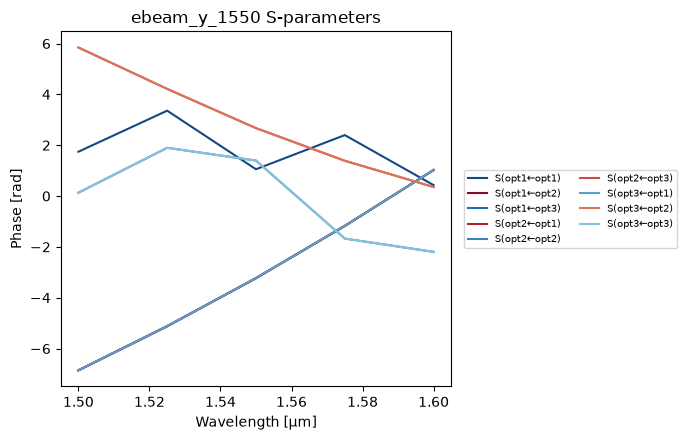

In [5]:
plot_smatrix(sm, kind="phase")
plt.show()

## 5 · Physical sanity checks

A passive, reciprocal device must obey `S = Sᵀ` and inject no energy. These
are your first line of defence against a mis-set simulation. Use an
engineering tolerance — real FDTD output carries ~1e-3 numerical asymmetry, so
a strict `atol=1e-6` would flag a physically-reciprocal device as not.

In [6]:
print("reciprocal (S = Sᵀ):", sm.is_reciprocal(atol=1e-2))
print("passive (no gain):  ", sm.is_passive(atol=1e-2))
pb = sm.power_balance()  # 1 - Σ|S|² per input, per wavelength (loss fraction)
print(f"power balance (loss fraction) over the band: {pb.min():.3f} … {pb.max():.3f}")

reciprocal (S = Sᵀ): True
passive (no gain):   True
power balance (loss fraction) over the band: 0.471 … 0.966


## 6 · Saving and sharing

One `SMatrix`, every standard format — Lumerical INTERCONNECT `.dat`,
Touchstone `.sNp` (for scikit-rf / ADS), HDF5, and npz. Each round-trips.

In [7]:
import tempfile  # noqa: E402

tmp = Path(tempfile.mkdtemp())
sm.to_dat(str(tmp / "ybranch.dat"))
sm.to_touchstone(str(tmp / "ybranch.s3p"))
sm.to_hdf5(str(tmp / "ybranch.h5"))
sm.to_npz(str(tmp / "ybranch.npz"))
print("wrote:", sorted(p.name for p in tmp.iterdir()))

# round-trip check through Touchstone
back = SMatrix.from_hdf5(str(tmp / "ybranch.h5"))
np.testing.assert_allclose(back.sel(out=2, in_=1), sm.sel(out=2, in_=1), rtol=1e-9)
print("HDF5 round-trip: identical ✓")

wrote: ['ybranch.dat', 'ybranch.h5', 'ybranch.npz', 'ybranch.s3p']
HDF5 round-trip: identical ✓


## Recap & next

The `SMatrix` is the common object across the toolbox: `sel` a path, read loss
and phase, check reciprocity/passivity, and export to any standard format, the
same regardless of which engine produced it.

- **`05_fields_and_modes`** — the spatial picture behind these numbers.
- **`06_convergence_and_caching`** — are the numbers converged?
- **`07_choosing_an_engine`** — do the engines agree on them?